<a href="https://colab.research.google.com/github/Henry-Gbriel/Curso-USP-An-lise-de-Dados---Esalq/blob/main/Analise_Fatorial_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Análise Fatorial por Componentes Principais (PCA)</h1>

In [3]:
import pandas as pd # manipular os dados no DataFrame
import numpy as np # Cálculos matemáticos
import matplotlib.pyplot as plt #Plotar os gráficos
from fractions import Fraction # Trabalahr com frações exatas

In [4]:
df = pd.DataFrame({'var_1':[10,11,8,3,2,1],
                   'var_2':[6,4,5,3,2.8,1]}) # Matriz - 6 linha e duas colunas

In [5]:
print(df)

   var_1  var_2
0     10    6.0
1     11    4.0
2      8    5.0
3      3    3.0
4      2    2.8
5      1    1.0


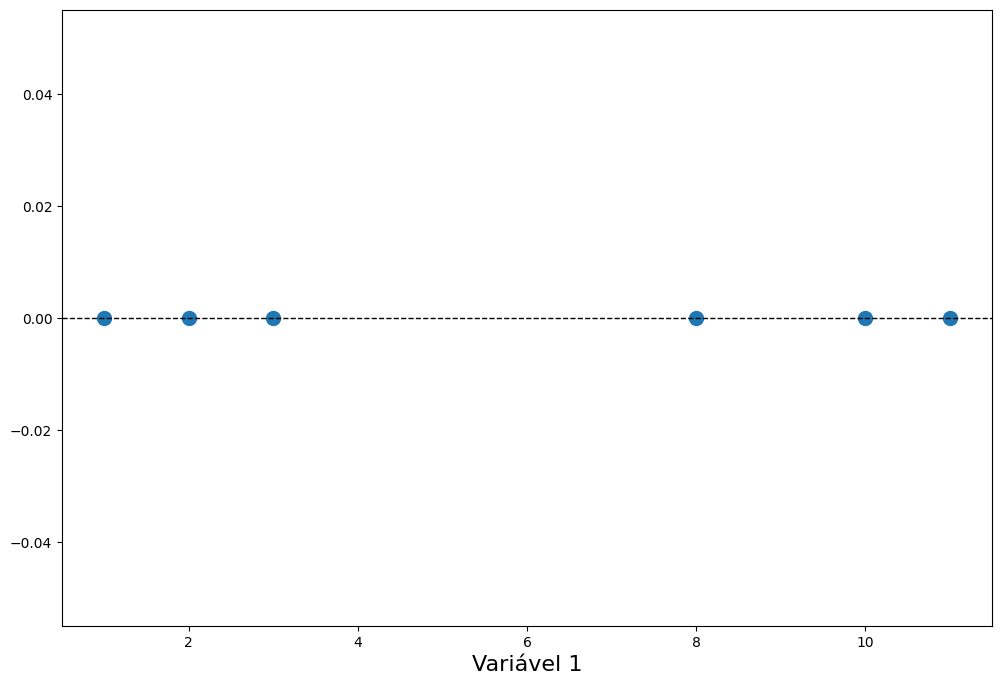

In [6]:
# Aqui plotamos somente os valores de var_1

plt.figure(figsize=(12,8))

plt.axhline(y=0, color='black', linewidth = 1, ls='--')
plt.scatter(df.var_1,[0] * df.shape[0], s=100)
plt.xlabel("Variável 1", fontsize=16)
plt.show() #Aqui podemos ver a dispersão dos pontos existentes

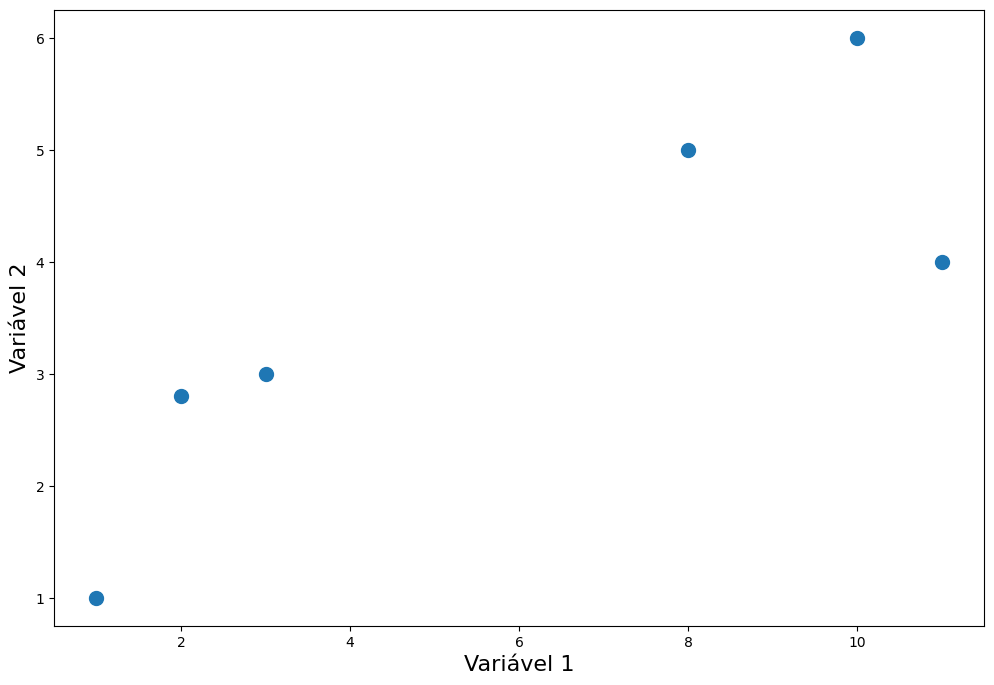

In [7]:
#Aqui plotamos var_1 e var_2
plt.figure(figsize=(12,8))

plt.scatter(df.var_1, df.var_2, s=100)
plt.xlabel("Variável 1", fontsize=16)
plt.ylabel("Variável 2", fontsize=16)
plt.show() #Agora aqui temos uma variavel dependente da outra


In [8]:
#Encontrando as médias das variáveis


'''
  Na sequência da teoria do PCA estamos centralizando

    Xc = X - Media(X)
'''
medias = df.T.mean(axis=1)

print(medias)

var_1    5.833333
var_2    3.633333
dtype: float64


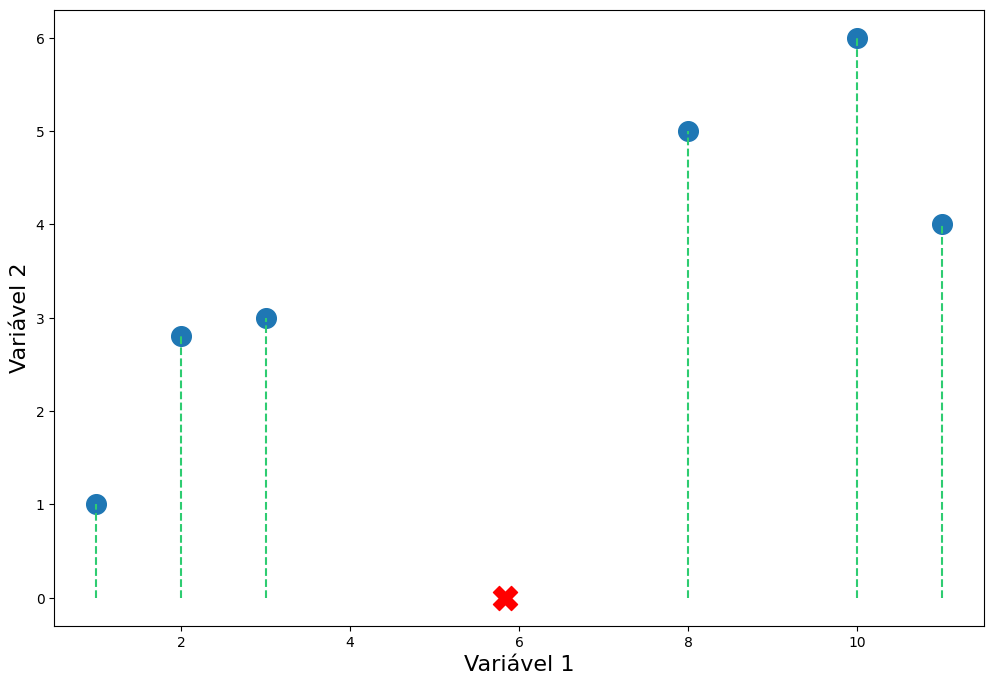

In [9]:
media_x, media_y = medias #aqui encontra o centro


#Encontrando as médias das variável 1 no gráfico

plt.figure(figsize=(12,8))


# Transformando as colunas em arrays
x = df.var_1.values
y = df.var_2.values

plt.scatter(x, y, s=200)

for i in range(len(x)):
    plt.plot([x[i],x[i]], [0,y[i]],'--', color='#2ecc71')

plt.scatter(media_x,0, marker="X", s=300, color='r')

plt.xlabel("Variável 1", fontsize=16)
plt.ylabel("Variável 2", fontsize=16)
plt.show() # Aqui mostra média dendo do grafico

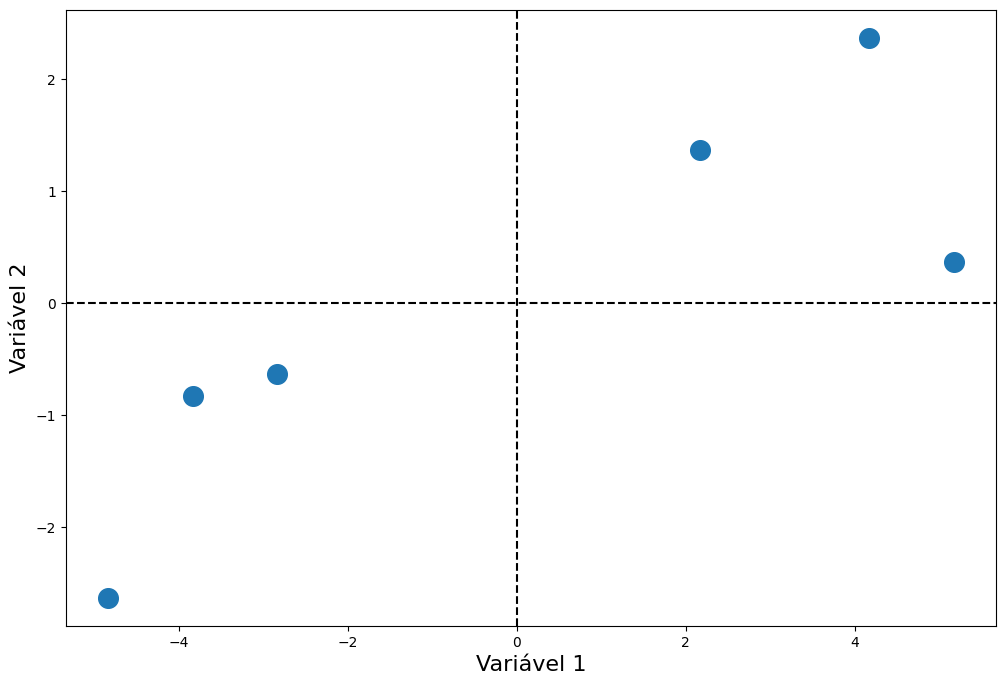

In [10]:
x_trans = x - media_x # centralização
y_trans = y - media_y #centralização


#%% Transladar eixo do gráfico para o centro através das médias das observações


plt.figure(figsize=(12,8))

plt.scatter(x_trans, y_trans, s=200)
plt.axhline(y=0, color='black', ls='--')
plt.axvline(x=0, color='black', ls='--')
plt.xlabel("Variável 1", fontsize=16)
plt.ylabel("Variável 2", fontsize=16)
plt.show()


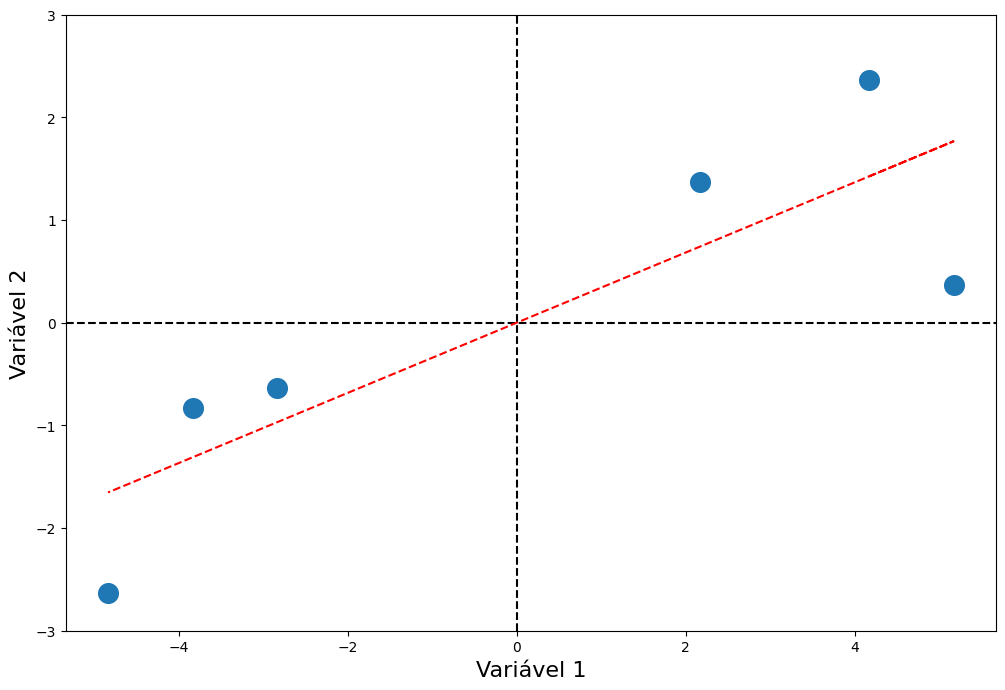

In [11]:
#Aqui estruturamos a matriz para regressão onde encontramos a melhor reta

plt.figure(figsize=(12,8))

A = np.vstack([x_trans, np.ones(len(x_trans))]).T #Matriz regressão

'''
  m ---> inclinação da reta
  c ---> interceptação da reta
'''

m, c = np.linalg.lstsq(A, y_trans, rcond=None)[0] # mínimo quadrado
m, c


x_fit = x_trans
pc1_fit = (m)*x_fit # ajustar a melhor curva

plt.scatter(x_trans, y_trans, s=200)
plt.axhline(y=0, color='black', ls='--')
plt.axvline(x=0, color='black', ls='--')
plt.plot(x_fit, pc1_fit, color='r', ls='--')
plt.ylim([-3,3])
plt.xlabel("Variável 1", fontsize=16)
plt.ylabel("Variável 2", fontsize=16)
plt.show()

In [12]:
coef_ang_pc1 = round(m,2) #Coeficiente Angular

print(coef_ang_pc1)


0.34


In [16]:
y_unit_pc1, x_unit_pc1 = Fraction(coef_ang_pc1).limit_denominator(1000).as_integer_ratio() # Trasformar em vetor

hipotenusa_pc1 = np.hypot(x_unit_pc1, y_unit_pc1) # Calculo da hipotenusa
'''
  Serve para saber qual é o tamanho do vetor

    √(x² + y²
'''


print(x_unit_pc1, y_unit_pc1, hipotenusa_pc1)


50 17 52.81098370604357


In [17]:
#Faz a normalização

# para var_1
x_unit_pc1/hipotenusa_pc1

# para var_1
y_unit_pc1/hipotenusa_pc1


np.float64(0.32190273323870233)

In [18]:
#Calcula a reta Perpendicalar ao PC1 que seria o PC2
print(f"PC 1: mistura de {round(x_unit_pc1/hipotenusa_pc1,3)} partes de var_1 com {round(y_unit_pc1/hipotenusa_pc1,3)} de var_2")


PC 1: mistura de 0.947 partes de var_1 com 0.322 de var_2


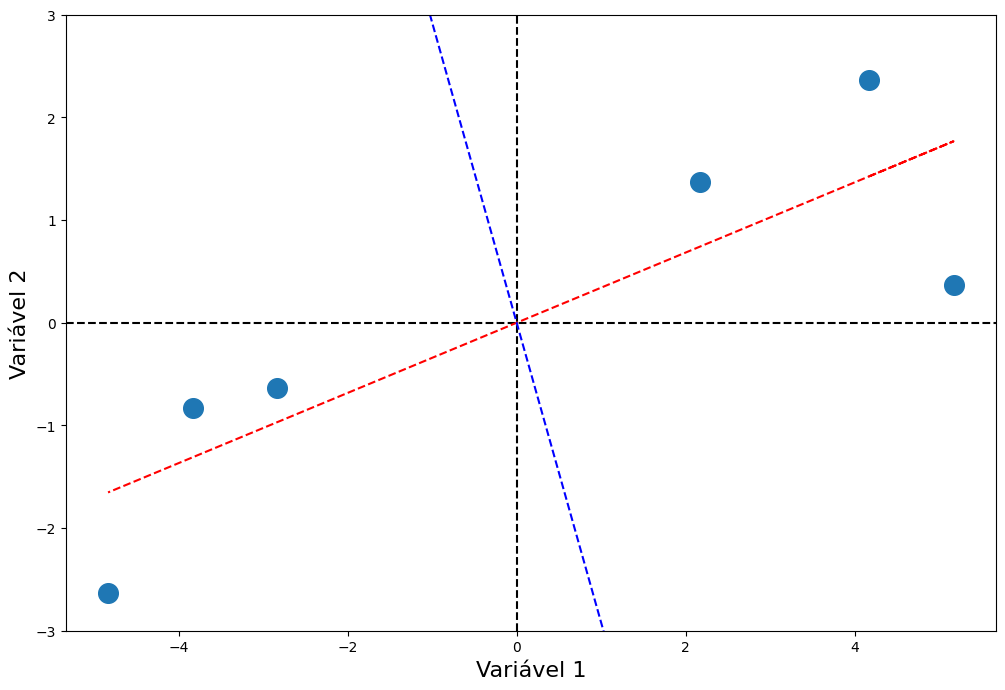

In [19]:
plt.figure(figsize=(12,8))

A = np.vstack([x_trans, np.ones(len(x_trans))]).T

m, c = np.linalg.lstsq(A, y_trans, rcond=None)[0]
m, c

pc2_slope = -1/m

x_fit = x_trans
pc1_fit = m*x_fit
pc2_fit = pc2_slope*x_fit

plt.scatter(x_trans, y_trans, s=200)
plt.axhline(y=0, color='black', ls='--')
plt.axvline(x=0, color='black', ls='--')

plt.plot(x_fit, pc1_fit, color='r', ls='--')
plt.plot(x_fit, pc2_fit, color='b', ls='--')
plt.ylim([-3,3])
plt.xlabel("Variável 1", fontsize=16)
plt.ylabel("Variável 2", fontsize=16)
plt.show()

In [20]:

coef_ang_pc2 = round(pc2_slope,2)

print(coef_ang_pc2)

y_unit_pc2, x_unit_pc2 = Fraction(coef_ang_pc2).limit_denominator(1000).as_integer_ratio()

y_unit_pc2 *= -1

x_unit_pc2 *= -1

hipotenusa_pc2 = np.hypot(x_unit_pc2, y_unit_pc2)

print(x_unit_pc2, y_unit_pc2, hipotenusa_pc2)

#%% Encontrar autovetor da combinação linear do segundo componente (PC2)

# para var_1
x_unit_pc2/hipotenusa_pc2

# para var_2
y_unit_pc2/hipotenusa_pc2


#%% Printar o resultado dos autovetores do PC2

print(f"PC 2: mistura de {round(x_unit_pc2/hipotenusa_pc2,2)} partes de var_1 com {round(y_unit_pc2/hipotenusa_pc2,2)} de var_2")

-2.92
-25 73 77.1621668954417
PC 2: mistura de -0.32 partes de var_1 com 0.95 de var_2
